In [1]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
#enable inline plotting
%matplotlib inline
import numpy as np
import requests
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
import requests
import pandas as pd
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from time import sleep

#API and date range
api_url = 'https://data.ny.gov/resource/wujg-7c2s.json'
limit = 50000
start_date = datetime(2020, 7, 1)
end_date = datetime(2024, 12, 31)

#Container for all raw data
all_data = []

#Loop through each month
current = start_date
while current <= end_date:
    start_str = current.strftime('%Y-%m-%dT00:00:00')
    end_str = (current + relativedelta(months=1) - timedelta(days=1)).strftime('%Y-%m-%dT23:59:59')
    where_clause = f"transit_timestamp between '{start_str}' and '{end_str}'"

    params = {
        '$limit': limit,
        '$where': where_clause
    }

    try:
        response = requests.get(api_url, params=params)
        response.raise_for_status()
        chunk = response.json()

        if chunk:
            all_data.extend(chunk)
            print(f" {current.strftime('%Y-%m')} — {len(chunk)} records")
        else:
            print(f"{current.strftime('%Y-%m')} — No data")

    except Exception as e:
        print(f"Error on {current.strftime('%Y-%m')}: {e}")

    current += relativedelta(months=1)
    sleep(1)  # Avoid throttling

#Convert to DataFrame
df = pd.DataFrame(all_data)
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'], errors='coerce')
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')

print(f"\n Finished fetching data — Total rows: {df.shape[0]}")
display(df.head())

 2020-07 — 50000 records
 2020-08 — 50000 records
 2020-09 — 50000 records
 2020-10 — 50000 records
 2020-11 — 50000 records
 2020-12 — 50000 records
 2021-01 — 50000 records
 2021-02 — 50000 records
 2021-03 — 50000 records
 2021-04 — 50000 records
 2021-05 — 50000 records
 2021-06 — 50000 records
 2021-07 — 50000 records
 2021-08 — 50000 records
 2021-09 — 50000 records
 2021-10 — 50000 records
 2021-11 — 50000 records
 2021-12 — 50000 records
 2022-01 — 50000 records
 2022-02 — 50000 records
 2022-03 — 50000 records
 2022-04 — 50000 records
 2022-05 — 50000 records
 2022-06 — 50000 records
 2022-07 — 50000 records
 2022-08 — 50000 records
 2022-09 — 50000 records
 2022-10 — 50000 records
 2022-11 — 50000 records
 2022-12 — 50000 records
 2023-01 — 50000 records
 2023-02 — 50000 records
 2023-03 — 50000 records
 2023-04 — 50000 records
 2023-05 — 50000 records
 2023-06 — 50000 records
 2023-07 — 50000 records
 2023-08 — 50000 records
 2023-09 — 50000 records
 2023-10 — 50000 records


,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2020-07-01,subway,358,"Newkirk Av-Little Haiti (2,5)",Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.63997,-73.94841,"{'type': 'Point', 'coordinates': [-73.94841, 4..."
1,2020-07-01,subway,136,New Lots Av (L),Brooklyn,metrocard,Metrocard - Full Fare,4.0,0.0,40.658733,-73.89923,"{'type': 'Point', 'coordinates': [-73.89923, 4..."
2,2020-07-01,subway,254,Jamaica-179 St (F),Queens,metrocard,Metrocard - Full Fare,1.0,1.0,40.712646,-73.78381,"{'type': 'Point', 'coordinates': [-73.78381, 4..."
3,2020-07-01,subway,354,"Sterling St (2,5)",Brooklyn,metrocard,Metrocard - Seniors & Disability,1.0,0.0,40.662743,-73.95085,"{'type': 'Point', 'coordinates': [-73.95085, 4..."
4,2020-07-01,subway,137,East 105 St (L),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.650574,-73.89948,"{'type': 'Point', 'coordinates': [-73.89948, 4..."


In [3]:
#save data from the api request into a csv file
df.to_csv('nyc_ridership_raw.csv', index=False)

In [4]:

#read the csv file for further data manipulation
df_data=pd.read_csv('nyc_ridership_raw.csv')

display(df_data) #check output

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2020-07-01 00:00:00,subway,358,"Newkirk Av-Little Haiti (2,5)",Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.639970,-73.94841,"{'type': 'Point', 'coordinates': [-73.94841, 4..."
1,2020-07-01 00:00:00,subway,136,New Lots Av (L),Brooklyn,metrocard,Metrocard - Full Fare,4.0,0.0,40.658733,-73.89923,"{'type': 'Point', 'coordinates': [-73.89923, 4..."
2,2020-07-01 00:00:00,subway,254,Jamaica-179 St (F),Queens,metrocard,Metrocard - Full Fare,1.0,1.0,40.712646,-73.78381,"{'type': 'Point', 'coordinates': [-73.78381, 4..."
3,2020-07-01 00:00:00,subway,354,"Sterling St (2,5)",Brooklyn,metrocard,Metrocard - Seniors & Disability,1.0,0.0,40.662743,-73.95085,"{'type': 'Point', 'coordinates': [-73.95085, 4..."
4,2020-07-01 00:00:00,subway,137,East 105 St (L),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.650574,-73.89948,"{'type': 'Point', 'coordinates': [-73.89948, 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2699995,2024-12-01 16:00:00,subway,46,Cortelyou Rd (Q),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,6.0,0.0,40.640926,-73.96389,"{'type': 'Point', 'coordinates': [-73.96389, 4..."
2699996,2024-12-01 16:00:00,subway,460,33 St-Rawson St (7),Queens,metrocard,Metrocard - Fair Fare,7.0,1.0,40.744587,-73.93100,"{'type': 'Point', 'coordinates': [-73.931, 40...."
2699997,2024-12-01 16:00:00,subway,460,33 St-Rawson St (7),Queens,omny,OMNY - Seniors & Disability,1.0,0.0,40.744587,-73.93100,"{'type': 'Point', 'coordinates': [-73.931, 40...."
2699998,2024-12-01 16:00:00,subway,461,"Queensboro Plaza (7,N,W)",Queens,metrocard,Metrocard - Unlimited 7-Day,34.0,0.0,40.750584,-73.94020,"{'type': 'Point', 'coordinates': [-73.9402, 40..."


In [5]:
df.isnull().sum() #make sure there are no null values

transit_timestamp      0
transit_mode           0
station_complex_id     0
station_complex        0
borough                0
payment_method         0
fare_class_category    0
ridership              0
transfers              0
latitude               0
longitude              0
georeference           0
dtype: int64

In [6]:
#drop unnecessary columns
df.drop(['georeference'], axis=1, inplace=True)
#print(df2)
df.dropna(inplace=True) #drop rows with null values
display(df)

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude
0,2020-07-01 00:00:00,subway,358,"Newkirk Av-Little Haiti (2,5)",Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.63997,-73.94841
1,2020-07-01 00:00:00,subway,136,New Lots Av (L),Brooklyn,metrocard,Metrocard - Full Fare,4.0,0.0,40.658733,-73.89923
2,2020-07-01 00:00:00,subway,254,Jamaica-179 St (F),Queens,metrocard,Metrocard - Full Fare,1.0,1.0,40.712646,-73.78381
3,2020-07-01 00:00:00,subway,354,"Sterling St (2,5)",Brooklyn,metrocard,Metrocard - Seniors & Disability,1.0,0.0,40.662743,-73.95085
4,2020-07-01 00:00:00,subway,137,East 105 St (L),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.650574,-73.89948
...,...,...,...,...,...,...,...,...,...,...,...
2699995,2024-12-01 16:00:00,subway,46,Cortelyou Rd (Q),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,6.0,0.0,40.640926,-73.96389
2699996,2024-12-01 16:00:00,subway,460,33 St-Rawson St (7),Queens,metrocard,Metrocard - Fair Fare,7.0,1.0,40.744587,-73.931
2699997,2024-12-01 16:00:00,subway,460,33 St-Rawson St (7),Queens,omny,OMNY - Seniors & Disability,1.0,0.0,40.744587,-73.931
2699998,2024-12-01 16:00:00,subway,461,"Queensboro Plaza (7,N,W)",Queens,metrocard,Metrocard - Unlimited 7-Day,34.0,0.0,40.750584,-73.9402


In [7]:
#create a copy of the original dataframe to work on
#to preserve the original just in case
df2=df_data.copy()
#display the data
display(df2.head(20))

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2020-07-01 00:00:00,subway,358,"Newkirk Av-Little Haiti (2,5)",Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.639970,-73.94841,"{'type': 'Point', 'coordinates': [-73.94841, 4..."
1,2020-07-01 00:00:00,subway,136,New Lots Av (L),Brooklyn,metrocard,Metrocard - Full Fare,4.0,0.0,40.658733,-73.89923,"{'type': 'Point', 'coordinates': [-73.89923, 4..."
2,2020-07-01 00:00:00,subway,254,Jamaica-179 St (F),Queens,metrocard,Metrocard - Full Fare,1.0,1.0,40.712646,-73.78381,"{'type': 'Point', 'coordinates': [-73.78381, 4..."
3,2020-07-01 00:00:00,subway,354,"Sterling St (2,5)",Brooklyn,metrocard,Metrocard - Seniors & Disability,1.0,0.0,40.662743,-73.95085,"{'type': 'Point', 'coordinates': [-73.95085, 4..."
4,2020-07-01 00:00:00,subway,137,East 105 St (L),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.650574,-73.89948,"{'type': 'Point', 'coordinates': [-73.89948, 4..."
5,2020-07-01 00:00:00,subway,136,New Lots Av (L),Brooklyn,metrocard,Metrocard - Unlimited 7-Day,2.0,0.0,40.658733,-73.89923,"{'type': 'Point', 'coordinates': [-73.89923, 4..."
6,2020-07-01 00:00:00,subway,246,Avenue I (F),Brooklyn,metrocard,Metrocard - Full Fare,3.0,0.0,40.625320,-73.97613,"{'type': 'Point', 'coordinates': [-73.97613, 4..."
7,2020-07-01 00:00:00,subway,45,Beverley Rd (Q),Brooklyn,metrocard,Metrocard - Full Fare,2.0,0.0,40.644030,-73.96449,"{'type': 'Point', 'coordinates': [-73.96449, 4..."
8,2020-07-01 00:00:00,subway,138,Canarsie-Rockaway Pkwy (L),Brooklyn,metrocard,Metrocard - Other,1.0,0.0,40.646652,-73.90185,"{'type': 'Point', 'coordinates': [-73.90185, 4..."
9,2020-07-01 00:00:00,subway,352,New Lots Av (3),Brooklyn,metrocard,Metrocard - Other,7.0,0.0,40.666237,-73.88408,"{'type': 'Point', 'coordinates': [-73.88408, 4..."


In [8]:
print(df2.dtypes)

transit_timestamp       object
transit_mode            object
station_complex_id      object
station_complex         object
borough                 object
payment_method          object
fare_class_category     object
ridership              float64
transfers              float64
latitude               float64
longitude              float64
georeference            object
dtype: object


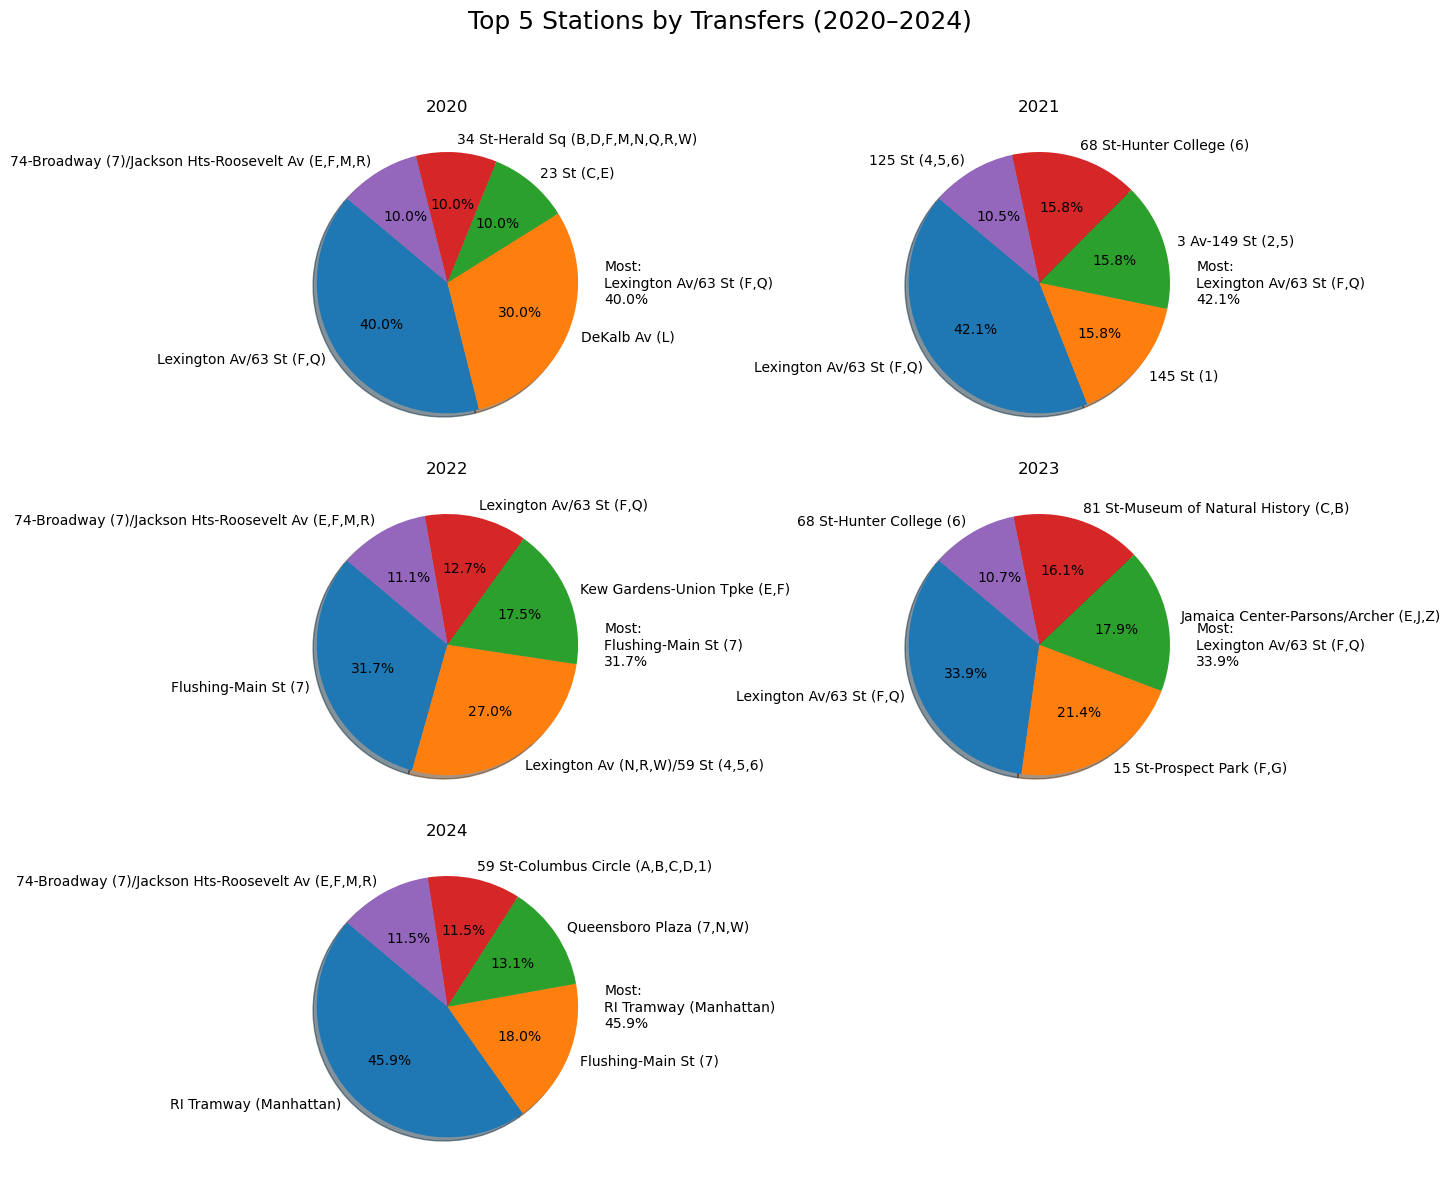

In [11]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Create an empty list to store data for each year
all_years = []

# Loop through years 2020 to 2024
for year in range(2020, 2025):
    # Make a request to get the data for one year
    url = f"https://data.ny.gov/resource/wujg-7c2s.json?$where=transit_timestamp between '{year}-01-01T00:00:00' and '{year}-12-31T23:59:59'"
    response = requests.get(url)
    df = pd.DataFrame(response.json())  # Turn the response into a DataFrame

    if not df.empty:  # Make sure data is not empty
        df['transfers'] = pd.to_numeric(df['transfers'], errors='coerce')  # Change transfer column to numbers
        df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'], errors='coerce')  # Change time column to datetime
        df = df[(df['transfers'] > 0) & df['transit_timestamp'].notna()]  # Keep only rows with valid data
        df['year'] = year  # Add the year column
        all_years.append(df)  # Add this year’s data to the list

# Combine all the years into one big DataFrame
combined = pd.concat(all_years, ignore_index=True)

# Set up the chart layout
years = list(range(2020, 2025))
rows = (len(years) + 1) // 2  # How many rows of charts we need
fig, axs = plt.subplots(rows, 2, figsize=(14, 4 * rows))  # Make a grid of pie charts

axs = axs.flatten()  # Turn axes into a simple list to loop through easily

# Make a pie chart for each year
for i, year in enumerate(years):
    year_df = combined[combined['year'] == year]  # Get data for the current year
    top_stations = year_df.groupby('station_complex')['transfers'].sum().nlargest(5).reset_index()  # Top 5 stations

    transfers = top_stations['transfers']
    labels = top_stations['station_complex']
    percent = (transfers / transfers.sum()) * 100  # Calculate percentages
    max_idx = percent.idxmax()  # Find the station with the highest percent

    axs[i].pie(transfers, labels=labels, autopct='%1.1f%%', startangle=140, shadow=True)  # Draw pie chart
    axs[i].set_title(f'{year}')  # Set title for this pie

    max_label = labels.iloc[max_idx]
    max_value = percent.iloc[max_idx]

    # Show the top station and its percent on the side
    axs[i].text(1.2, 0, f'Most:\n{max_label}\n{max_value:.1f}%', fontsize=10, ha='left', va='center')

# Remove any extra empty charts
for j in range(len(years), len(axs)):
    fig.delaxes(axs[j])

# Add main title and adjust layout
plt.suptitle("Top 5 Stations by Transfers (2020–2024)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()  # Show the full chart


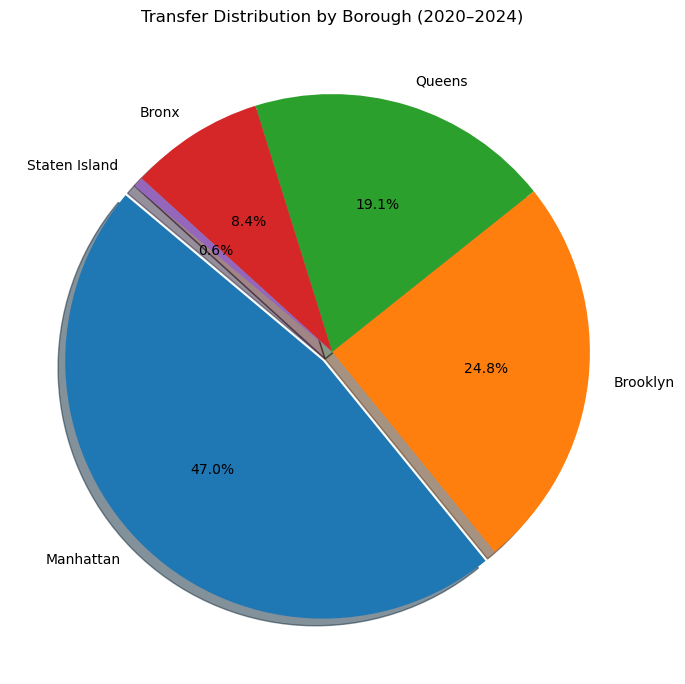

In [12]:
# Group data by borough and add up transfers, then sort from highest to lowest
boroughs = combined.groupby('borough')['transfers'].sum().reset_index().sort_values(by='transfers', ascending=False)

# Set the size of the pie chart
plt.figure(figsize=(7, 7))

# Create the pie chart
plt.pie(
    boroughs['transfers'],# Data for the slices
    labels=boroughs['borough'],# Labels for each slice
    autopct='%1.1f%%',# Show percentage with 1 decimal
    startangle=140,# Rotate the start angle for better layout
    shadow=True,# Add a shadow for 3D look
    explode=[0.05] + [0] * (len(boroughs) - 1)  # Pop out the first slice slightly
)

# Add a title to the chart
plt.title("Transfer Distribution by Borough (2020–2024)")

# Make sure the layout fits well
plt.tight_layout()

# Show the pie chart
plt.show()
